In [1]:
# ============================================================
# EXPLORER DATASET - QUALITY AUDIT AND CLEANING
# ============================================================
# Audits the raw CIHI/NACRS exports in data/Explorer Dataset and writes a cleaned
# copy of each file to data/Explorer Dataset/cleaned/ under the SAME file name.
#
# Nothing downstream changes: backend/database/load_csv.py reads the cleaned
# directory first and falls back to the raw files, so table names, column names,
# and the analytical schema are all untouched.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Locate the project root so the notebook runs from any working directory.
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "backend").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "Explorer Dataset"
CLEAN_DIR = RAW_DIR / "cleaned"

CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Raw folder   :", RAW_DIR)
print("Clean folder :", CLEAN_DIR)

Project root : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-
Raw folder   : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-\data\Explorer Dataset
Clean folder : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-\data\Explorer Dataset\cleaned


In [3]:
# Reuse the platform's own preprocessing vocabulary rather than restating it here,
# so the notebook and the backend cannot drift apart.
from backend.analytics.preprocessing.cleaning import (
    AGE_GROUP_CANONICAL,
    POPULATION_CATEGORY_MAP,
    normalize_age_group,
    normalize_population_category,
)

print("Canonical age groups :", AGE_GROUP_CANONICAL)
print()
print("Population category map:")

for k, v in POPULATION_CATEGORY_MAP.items():
    print(f"  {k!r:28} -> {v}")

Canonical age groups : ['0-19', '20-44', '45-64', '65+']

Population category map:
  '0-19'                       -> Pediatric & Youth
  '0–19'                       -> Pediatric & Youth
  '00-19'                      -> Pediatric & Youth
  '00–19'                      -> Pediatric & Youth
  '20-44'                      -> Young Adult
  '20–44'                      -> Young Adult
  '45-64'                      -> Middle Adult
  '45–64'                      -> Middle Adult
  '65+'                        -> Older Adult
  '65 and over'                -> Older Adult
  '65 and older'               -> Older Adult


In [4]:
DATASETS = [
    "CTAS_Triage",
    "Visit_Disposition",
    "Age_Sex",
    "Main_Problems",
    "ED_Visits",
    "Demographics",
]

raw_frames = {}

for name in DATASETS:
    path = RAW_DIR / f"{name}.csv"
    if path.exists():
        raw_frames[name] = pd.read_csv(path)
        print(f"  loaded {name:20} {raw_frames[name].shape}")
    else:
        print(f"  SKIP   {name:20} (no {path.name})")

  loaded CTAS_Triage          (912, 10)
  loaded Visit_Disposition    (936, 12)
  SKIP   Age_Sex              (no Age_Sex.csv)
  loaded Main_Problems        (1063, 10)
  loaded ED_Visits            (7296, 11)
  loaded Demographics         (36, 8)


In [5]:
print("SHAPE AND COLUMN INVENTORY")
print("=" * 80)

inventory = pd.DataFrame([
    {"dataset": n, "rows": len(d), "columns": d.shape[1]}
    for n, d in raw_frames.items()
])

display(inventory)

SHAPE AND COLUMN INVENTORY


,dataset,rows,columns
0,CTAS_Triage,912,10
1,Visit_Disposition,936,12
2,Main_Problems,1063,10
3,ED_Visits,7296,11
4,Demographics,36,8


In [6]:
print("MISSING VALUES AND DUPLICATES")
print("=" * 80)

quality = pd.DataFrame([
    {
        "dataset": n,
        "duplicate_rows": int(d.duplicated().sum()),
        "null_cells": int(d.isna().sum().sum()),
        "columns_with_nulls": int((d.isna().sum() > 0).sum()),
    }
    for n, d in raw_frames.items()
])

display(quality)

MISSING VALUES AND DUPLICATES


,dataset,duplicate_rows,null_cells,columns_with_nulls
0,CTAS_Triage,0,0,0
1,Visit_Disposition,0,0,0
2,Main_Problems,0,0,0
3,ED_Visits,0,0,0
4,Demographics,0,0,0


In [7]:
# ------------------------------------------------------------
# DEFECT 1 - AGGREGATE ROWS EMBEDDED IN DETAIL ROWS
# ------------------------------------------------------------
# ED_Visits carries roll-up categories in the same table as the detail rows.
# Summing ed_visits without removing them double counts every visit.

AGGREGATE_LABELS = {
    "visit_disposition": ["Total"],
    "main_problem": ["Any"],
    "triage_level": ["Total"],
}

print("AGGREGATE ROW AUDIT")
print("=" * 80)

for name, df in raw_frames.items():
    for column, labels in AGGREGATE_LABELS.items():
        if column not in df.columns:
            continue
        hit = df[df[column].isin(labels)]
        if hit.empty:
            continue
        detail = df[~df[column].isin(labels)]
        print(f"\n{name}.{column}")
        print(f"  aggregate rows   : {len(hit):,}")
        print(f"  aggregate visits : {hit['ed_visits'].sum():,.0f}")
        print(f"  detail visits    : {detail['ed_visits'].sum():,.0f}")
        if detail["ed_visits"].sum() > 0:
            ratio = hit["ed_visits"].sum() / detail["ed_visits"].sum()
            print(f"  inflation if kept: {ratio:.1%}")

AGGREGATE ROW AUDIT

ED_Visits.visit_disposition
  aggregate rows   : 912
  aggregate visits : 223,510,207
  detail visits    : 223,510,207
  inflation if kept: 100.0%

ED_Visits.main_problem
  aggregate rows   : 912
  aggregate visits : 351,576,066
  detail visits    : 95,444,348
  inflation if kept: 368.4%


In [8]:
# ------------------------------------------------------------
# DEFECT 2 - INCONSISTENT AGE GROUP ENCODING
# ------------------------------------------------------------
# CTAS_Triage writes en dashes ("00-19" with U+2013); the other exports use plain
# hyphens. A join on age_group silently produces zero matches between them.

print("AGE GROUP ENCODING AUDIT")
print("=" * 80)

for name, df in raw_frames.items():
    if "age_group" not in df.columns:
        continue
    values = sorted(df["age_group"].dropna().astype(str).unique())
    print(f"\n{name}")
    for v in values:
        codepoints = " ".join(f"U+{ord(ch):04X}" for ch in v if not ch.isalnum())
        print(f"  {v!r:12} non-alphanumeric: {codepoints or 'none'}")

AGE GROUP ENCODING AUDIT

CTAS_Triage
  '00–19'      non-alphanumeric: U+2013
  '20–44'      non-alphanumeric: U+2013
  '45–64'      non-alphanumeric: U+2013
  '65+'        non-alphanumeric: U+002B

Visit_Disposition
  '0-19'       non-alphanumeric: U+002D
  '20-44'      non-alphanumeric: U+002D
  '45-64'      non-alphanumeric: U+002D
  '65+'        non-alphanumeric: U+002B

Main_Problems
  '0-19'       non-alphanumeric: U+002D
  '20-44'      non-alphanumeric: U+002D
  '45-64'      non-alphanumeric: U+002D
  '65+'        non-alphanumeric: U+002B

Demographics
  '0-19'       non-alphanumeric: U+002D
  '20-44'      non-alphanumeric: U+002D
  '45-64'      non-alphanumeric: U+002D
  '65+'        non-alphanumeric: U+002B


In [9]:
# ------------------------------------------------------------
# DEFECT 3 - DEGENERATE CTAS URGENCY SCORE
# ------------------------------------------------------------
# ctas_urgency_score is the predictor behind H3. If several distinct acuity levels
# share one score, the regression cannot separate them.

print("CTAS URGENCY SCORE AUDIT")
print("=" * 80)

ctas = raw_frames.get("CTAS_Triage")

if ctas is not None and "ctas_urgency_score" in ctas.columns:
    mapping = (
        ctas.groupby("triage_level")["ctas_urgency_score"]
        .agg(["min", "max", "nunique"])
        .reset_index()
    )
    display(mapping)

    collisions = (
        ctas.groupby("ctas_urgency_score")["triage_level"]
        .nunique()
        .reset_index(name="distinct_triage_levels")
    )
    display(collisions)

    worst = int(collisions["distinct_triage_levels"].max())
    print(f"Maximum triage levels sharing a single score: {worst}")

CTAS URGENCY SCORE AUDIT


,triage_level,min,max,nunique
0,CTAS I - Resuscitation,1,1,1
1,CTAS II - Emergent,2,2,1
2,CTAS III - Urgent,3,3,1
3,Less urgent,3,3,1
4,Non-urgent,3,3,1
5,Unknown,3,3,1


,ctas_urgency_score,distinct_triage_levels
0,1,1
1,2,1
2,3,4


Maximum triage levels sharing a single score: 4


In [10]:
# ------------------------------------------------------------
# DEFECT 4 - SUPPRESSED CELLS REPORTED AS ZERO
# ------------------------------------------------------------
# CIHI suppresses small counts. Those cells arrive as 0 rather than as missing,
# and a zero-visit row carries no weight and no usable LOS.

print("SUPPRESSED CELL AUDIT")
print("=" * 80)

for name, df in raw_frames.items():
    if "ed_visits" not in df.columns:
        continue
    zero_visits = int((df["ed_visits"] <= 0).sum())
    share = zero_visits / len(df) * 100 if len(df) else 0
    print(f"  {name:20} ed_visits <= 0 : {zero_visits:>6,} of {len(df):>6,} ({share:5.1f}%)")

SUPPRESSED CELL AUDIT
  CTAS_Triage          ed_visits <= 0 :      0 of    912 (  0.0%)
  Visit_Disposition    ed_visits <= 0 :      0 of    936 (  0.0%)
  Main_Problems        ed_visits <= 0 :     26 of  1,063 (  2.4%)
  ED_Visits            ed_visits <= 0 :  2,247 of  7,296 ( 30.8%)


In [11]:
# ------------------------------------------------------------
# DEFECT 5 - PLACEHOLDER CATEGORIES
# ------------------------------------------------------------
# "Unknown" is a reporting artefact, not a clinical group. It cannot take part in
# an acuity-ordered or disposition-ordered comparison.

PLACEHOLDERS = {"Unknown", "Not Stated", "Missing", ""}

print("PLACEHOLDER CATEGORY AUDIT")
print("=" * 80)

for name, df in raw_frames.items():
    for column in ("triage_level", "visit_disposition", "sex", "age_group"):
        if column not in df.columns:
            continue
        hit = df[df[column].astype(str).str.strip().isin(PLACEHOLDERS)]
        if not hit.empty:
            visits = hit["ed_visits"].sum() if "ed_visits" in hit.columns else 0
            print(f"  {name}.{column}: {len(hit):,} rows, {visits:,.0f} visits")

PLACEHOLDER CATEGORY AUDIT
  CTAS_Triage.triage_level: 152 rows, 1,555,549 visits
  Visit_Disposition.visit_disposition: 24 rows, 143,171 visits
  ED_Visits.triage_level: 1,216 rows, 3,595,610 visits
  ED_Visits.visit_disposition: 912 rows, 188,330 visits


In [12]:
# ------------------------------------------------------------
# DEFECT 6 - DERIVED LOS COLUMNS OUT OF STEP
# ------------------------------------------------------------
# median_los_hours must equal median_los_minutes / 60.

print("DERIVED COLUMN CONSISTENCY")
print("=" * 80)

for name, df in raw_frames.items():
    if not {"median_los_minutes", "median_los_hours"}.issubset(df.columns):
        continue
    minutes = pd.to_numeric(df["median_los_minutes"], errors="coerce")
    hours = pd.to_numeric(df["median_los_hours"], errors="coerce")
    drift = (minutes / 60 - hours).abs()
    print(f"  {name:20} rows off by > 0.01 h: {int((drift > 0.01).sum()):,}")

DERIVED COLUMN CONSISTENCY
  CTAS_Triage          rows off by > 0.01 h: 0
  Visit_Disposition    rows off by > 0.01 h: 0
  Main_Problems        rows off by > 0.01 h: 0
  ED_Visits            rows off by > 0.01 h: 0


In [13]:
# ============================================================
# CLEANING RULES
# ============================================================
# The Explorer Dataset backs the user-facing dataset explorer, so the guiding rule is
# CONSERVATIVE: correct what is wrong, flag what is incomplete, and delete only what is
# actively misleading AND recoverable. Nothing that carries information is discarded.
#
#   Corrected  - punctuation, casing, derived columns, merge artefacts.
#   Flagged    - suppressed cells get is_suppressed = 1; the rows stay.
#   Removed    - roll-up rows only. They double count, and any explorer can recover a
#                total by summing the detail, so removing them loses nothing.
#
# Measured values (ed_visits, median_los_minutes) are never rewritten or imputed.

def clean_dataset(name, df):
    report = {"dataset": name, "rows_in": len(df)}
    out = df.copy()

    # 1. Normalise column names to snake_case.
    out.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in out.columns]

    # 2. Drop the duplicated population_category.1 artefact left by an earlier merge.
    #    The surviving population_category column carries the same information.
    artefacts = [c for c in out.columns if c.endswith(".1") or c.endswith("_1")]
    out = out.drop(columns=artefacts, errors="ignore")
    report["artefact_columns_dropped"] = len(artefacts)

    # 3. Remove exact duplicate rows.
    before = len(out)
    out = out.drop_duplicates()
    report["duplicates_removed"] = before - len(out)

    # 4. Remove roll-up rows. This is the one deletion, and it is the one that matters:
    #    ED_Visits' "Total" rows equal the detail sum exactly, so leaving them in makes
    #    every unfiltered total twice the truth.
    removed_aggregate = 0
    for column, labels in AGGREGATE_LABELS.items():
        if column in out.columns:
            before = len(out)
            out = out[~out[column].isin(labels)]
            removed_aggregate += before - len(out)
    report["aggregate_rows_removed"] = removed_aggregate

    # 5. Canonicalise the shared categorical vocabularies so cross-file joins work.
    #    Labels are re-punctuated, never re-bucketed.
    if "age_group" in out.columns:
        out["age_group"] = out["age_group"].map(normalize_age_group)
    if "population_category" in out.columns:
        out["population_category"] = out["population_category"].map(normalize_population_category)

    # 6. FLAG suppressed cells rather than deleting them. CIHI reports small counts as 0.
    #    The explorer should still show that the cell exists and was suppressed; the
    #    hypothesis engines filter on ed_visits > 0 in SQL and so ignore them anyway.
    if "ed_visits" in out.columns:
        out["ed_visits"] = pd.to_numeric(out["ed_visits"], errors="coerce")
        out["is_suppressed"] = (out["ed_visits"].isna() | (out["ed_visits"] <= 0)).astype(int)
        report["suppressed_rows_flagged"] = int(out["is_suppressed"].sum())

    # 7. Coerce LOS to numeric and flag impossible values. Negative LOS is physically
    #    meaningless, so those cells are blanked - but the row survives.
    if "median_los_minutes" in out.columns:
        out["median_los_minutes"] = pd.to_numeric(out["median_los_minutes"], errors="coerce")
        impossible = out["median_los_minutes"] < 0
        report["negative_los_blanked"] = int(impossible.sum())
        out.loc[impossible, "median_los_minutes"] = np.nan

    # 8. Recompute the derived hours column from the authoritative minutes column.
    if "median_los_minutes" in out.columns:
        out["median_los_hours"] = (out["median_los_minutes"] / 60).round(4)

    report["rows_out"] = len(out)
    return out, report


print("clean_dataset defined.")

clean_dataset defined.


In [14]:
clean_frames = {}
reports = []

for name, df in raw_frames.items():
    cleaned, report = clean_dataset(name, df)
    clean_frames[name] = cleaned
    reports.append(report)

report_df = pd.DataFrame(reports).fillna(0)

print("CLEANING REPORT")
print("=" * 80)

display(report_df)

CLEANING REPORT


,dataset,rows_in,artefact_columns_dropped,duplicates_removed,aggregate_rows_removed,suppressed_rows_flagged,negative_los_blanked,rows_out
0,CTAS_Triage,912,0,0,0,0.0,0.0,912
1,Visit_Disposition,936,0,0,0,0.0,0.0,936
2,Main_Problems,1063,0,0,0,26.0,0.0,1063
3,ED_Visits,7296,0,0,1710,2073.0,0.0,5586
4,Demographics,36,1,0,0,0.0,0.0,36


In [15]:
# Placeholder categories are RETAINED in the cleaned files and excluded at analysis
# time instead. Dropping them here would remove them from the dataset explorer, where
# they are legitimately interesting as a data-completeness signal.

print("PLACEHOLDER HANDLING")
print("=" * 80)
print("Retained in the cleaned CSVs; excluded by the hypothesis engines via")
print("backend.analytics.hypothesis_testing.EXCLUDED_CATEGORIES.")
print()

from backend.analytics.hypothesis_testing import EXCLUDED_CATEGORIES

print("EXCLUDED_CATEGORIES =", EXCLUDED_CATEGORIES)

PLACEHOLDER HANDLING
Retained in the cleaned CSVs; excluded by the hypothesis engines via
backend.analytics.hypothesis_testing.EXCLUDED_CATEGORIES.

EXCLUDED_CATEGORIES = ('Unknown', 'Not Stated', 'Missing', '')


In [16]:
print("POST-CLEAN VOCABULARY CHECK")
print("=" * 80)

for name, df in clean_frames.items():
    for column in ("age_group", "population_category"):
        if column in df.columns:
            print(f"  {name:20} {column:20} {sorted(df[column].dropna().unique())}")

POST-CLEAN VOCABULARY CHECK
  CTAS_Triage          age_group            ['0-19', '20-44', '45-64', '65+']
  CTAS_Triage          population_category  ['Middle Adult', 'Older Adult', 'Pediatric & Youth', 'Young Adult']
  Visit_Disposition    age_group            ['0-19', '20-44', '45-64', '65+']
  Visit_Disposition    population_category  ['Middle Adult', 'Older Adult', 'Pediatric & Youth', 'Young Adult']
  Main_Problems        age_group            ['0-19', '20-44', '45-64', '65+']
  Main_Problems        population_category  ['Middle Adult', 'Older Adult', 'Pediatric & Youth', 'Young Adult']
  Demographics         age_group            ['0-19', '20-44', '45-64', '65+']
  Demographics         population_category  ['Adult', 'Senior']


In [17]:
# Cross-file joinability is the point of canonicalising age_group: the same key must
# now match across every export that carries it.

print("CROSS-FILE AGE GROUP JOINABILITY")
print("=" * 80)

age_sets = {
    n: set(d["age_group"].dropna().unique())
    for n, d in clean_frames.items() if "age_group" in d.columns
}

names = list(age_sets)

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = age_sets[names[i]], age_sets[names[j]]
        shared = a & b
        print(f"  {names[i]:18} vs {names[j]:18} shared keys: {len(shared)} / {len(a | b)}")

CROSS-FILE AGE GROUP JOINABILITY
  CTAS_Triage        vs Visit_Disposition  shared keys: 4 / 4
  CTAS_Triage        vs Main_Problems      shared keys: 4 / 4
  CTAS_Triage        vs Demographics       shared keys: 4 / 4
  Visit_Disposition  vs Main_Problems      shared keys: 4 / 4
  Visit_Disposition  vs Demographics       shared keys: 4 / 4
  Main_Problems      vs Demographics       shared keys: 4 / 4


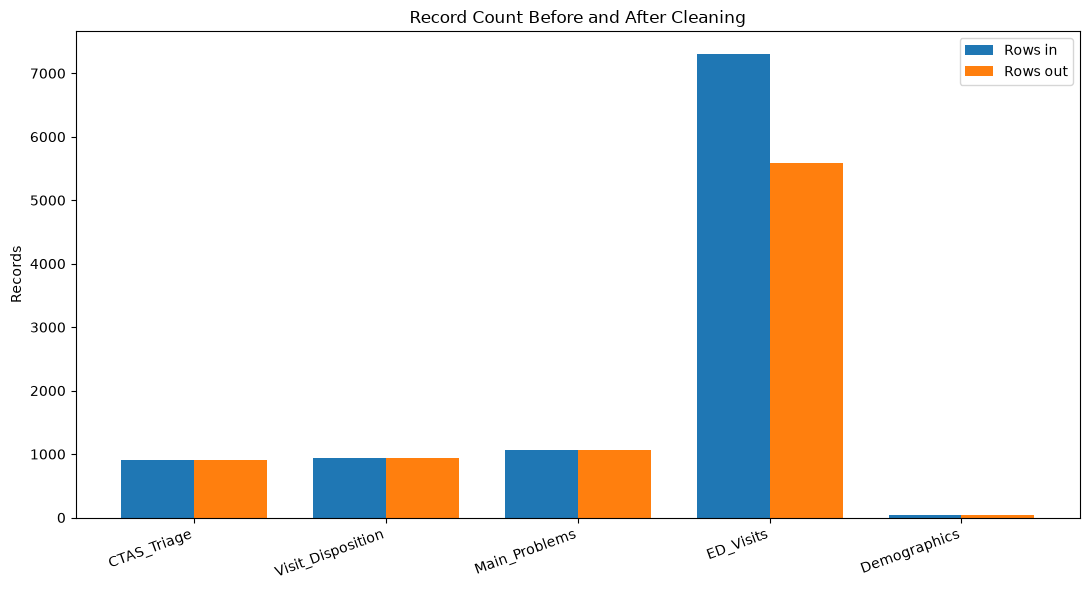

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(report_df))
width = 0.38

ax.bar(x - width / 2, report_df["rows_in"], width, label="Rows in")
ax.bar(x + width / 2, report_df["rows_out"], width, label="Rows out")

ax.set_xticks(x)
ax.set_xticklabels(report_df["dataset"], rotation=20, ha="right")
ax.set_ylabel("Records")
ax.set_title("Record Count Before and After Cleaning")
ax.legend()

plt.tight_layout()
plt.show()

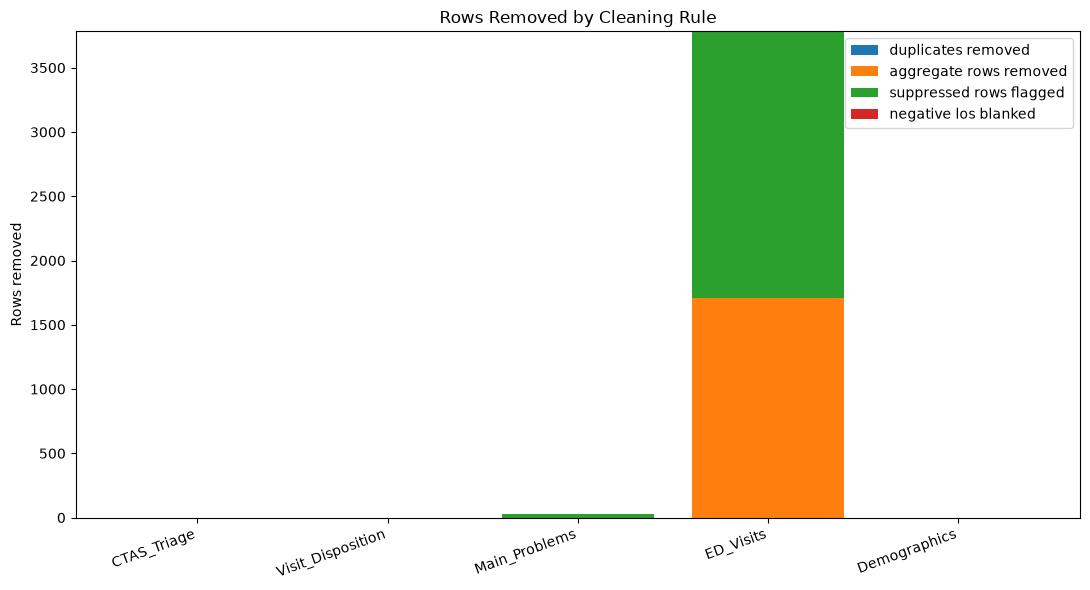

In [19]:
removal_cols = [
    "duplicates_removed",
    "aggregate_rows_removed",
    "suppressed_rows_flagged",
    "negative_los_blanked",
]

present = [c for c in removal_cols if c in report_df.columns]

fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(len(report_df))

for col in present:
    values = report_df[col].to_numpy(dtype=float)
    ax.bar(report_df["dataset"], values, bottom=bottom, label=col.replace("_", " "))
    bottom += values

ax.set_ylabel("Rows removed")
ax.set_title("Rows Removed by Cleaning Rule")
ax.set_xticks(range(len(report_df)))
ax.set_xticklabels(report_df["dataset"], rotation=20, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# CLEANED DATA - PRESENTATION VIEW
# ============================================================
# What an explorer user actually sees after cleaning.

for name, df in clean_frames.items():
    print("=" * 80)
    print(f"{name}   {df.shape[0]:,} rows x {df.shape[1]} columns")
    print("=" * 80)
    display(df.head(8))
    print()

CTAS_Triage   912 rows x 11 columns


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,is_suppressed
0,2021-2022,2021,Female,CTAS I - Resuscitation,1,0-19,Pediatric & Youth,10332,240.0,4.0,0
1,2021-2022,2021,Female,CTAS I - Resuscitation,1,20-44,Young Adult,11051,330.0,5.5,0
2,2021-2022,2021,Female,CTAS I - Resuscitation,1,45-64,Middle Adult,11653,324.0,5.4,0
3,2021-2022,2021,Female,CTAS I - Resuscitation,1,65+,Older Adult,25787,414.0,6.9,0
4,2021-2022,2021,Male,CTAS I - Resuscitation,1,0-19,Pediatric & Youth,12409,228.0,3.8,0
5,2021-2022,2021,Male,CTAS I - Resuscitation,1,20-44,Young Adult,18848,336.0,5.6,0
6,2021-2022,2021,Male,CTAS I - Resuscitation,1,45-64,Middle Adult,20762,300.0,5.0,0
7,2021-2022,2021,Male,CTAS I - Resuscitation,1,65+,Older Adult,30338,360.0,6.0,0



Visit_Disposition   936 rows x 13 columns


,fiscal_year,fiscal_year_start,sex,visit_disposition,admission_flag,admission_status,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,erbi,is_suppressed
0,2021-2022,2021,Female,Admitted,1,Admitted,0-19,Pediatric & Youth,61448,450.0,7.5,27651600,0
1,2021-2022,2021,Female,Admitted,1,Admitted,20-44,Young Adult,135970,702.0,11.7,95450940,0
2,2021-2022,2021,Female,Admitted,1,Admitted,45-64,Middle Adult,154636,792.0,13.2,122471712,0
3,2021-2022,2021,Female,Admitted,1,Admitted,65+,Older Adult,423379,966.0,16.1,408984114,0
4,2021-2022,2021,Male,Admitted,1,Admitted,0-19,Pediatric & Youth,61089,420.0,7.0,25657380,0
5,2021-2022,2021,Male,Admitted,1,Admitted,20-44,Young Adult,135841,720.0,12.0,97805520,0
6,2021-2022,2021,Male,Admitted,1,Admitted,45-64,Middle Adult,197560,762.0,12.7,150540720,0
7,2021-2022,2021,Male,Admitted,1,Admitted,65+,Older Adult,403171,906.0,15.1,365272926,0



Main_Problems   1,063 rows x 11 columns


,fiscal_year,fiscal_year_start,sex,main_problem,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,erbi,is_suppressed
0,2021-2022,2021,Female,Acute Myocardial Infarction,0-19,Pediatric & Youth,0,216.0,3.6,0,1
1,2021-2022,2021,Female,Acute Myocardial Infarction,20-44,Young Adult,291,450.0,7.5,130950,0
2,2021-2022,2021,Female,Acute Myocardial Infarction,45-64,Middle Adult,2485,408.0,6.8,1013880,0
3,2021-2022,2021,Female,Acute Myocardial Infarction,65+,Older Adult,6555,498.0,8.3,3264390,0
4,2021-2022,2021,Female,Asthma,0-19,Pediatric & Youth,7013,222.0,3.7,1556886,0
5,2021-2022,2021,Female,Asthma,20-44,Young Adult,7392,186.0,3.1,1374912,0
6,2021-2022,2021,Female,Asthma,45-64,Middle Adult,3715,216.0,3.6,802440,0
7,2021-2022,2021,Female,Asthma,65+,Older Adult,2010,276.0,4.6,554760,0



ED_Visits   5,586 rows x 12 columns


,fiscal_year,fiscal_year_start,triage_level,ctas_urgency_score,visit_disposition,main_problem,admission_status,ed_visits,median_los_minutes,median_los_hours,admission_flag,is_suppressed
0,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Acute Myocardial Infarction,Admitted,1360,93.0,1.55,1,0
2,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Asthma,Admitted,822,456.0,7.60,1,0
3,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Influenzal Pneumonia,Admitted,0,0.0,0.00,1,1
4,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Motor Vehicle Collisions,Admitted,3032,324.0,5.40,1,0
5,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Pneumonia,Admitted,1656,561.0,9.35,1,0
6,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Trauma,Admitted,8476,348.0,5.80,1,0
7,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Unintentional Falls,Admitted,2393,456.0,7.60,1,0
8,2021-2022,2021,CTAS I - Resuscitation,1,Death,Acute Myocardial Infarction,Not Admitted,365,36.0,0.60,0,0



Demographics   36 rows x 7 columns


,sex,age_group,population_category,visit_percentage,median_los_hours,total_visits,avg_length_of_stay_min
0,Male,0-19,Adult,1.13,2.01,7913347,120.7
1,Male,0-19,Adult,0.54,1.94,3809010,116.2
2,Male,0-19,Adult,0.52,2.00,3660211,120.3
3,Male,0-19,Adult,0.68,2.16,4765641,129.3
4,Male,20-44,Adult,0.80,2.29,5622253,137.5
5,Male,20-44,Adult,0.78,2.33,5491540,140.0
6,Male,20-44,Adult,0.75,2.39,5244347,143.2
7,Male,20-44,Adult,0.73,2.45,5110928,147.1


In [21]:
# Analysable coverage: how much of each dataset carries a usable visit weight.

coverage = []

for name, df in clean_frames.items():
    if "ed_visits" not in df.columns:
        continue
    usable = df[df["is_suppressed"] == 0]
    coverage.append({
        "dataset": name,
        "rows": len(df),
        "analysable_rows": len(usable),
        "suppressed_rows": int(df["is_suppressed"].sum()),
        "coverage_%": round(len(usable) / len(df) * 100, 1) if len(df) else 0.0,
        "total_visits": int(usable["ed_visits"].sum()),
    })

coverage_df = pd.DataFrame(coverage)

print("ANALYSABLE COVERAGE AFTER CLEANING")
print("=" * 80)

display(coverage_df)

ANALYSABLE COVERAGE AFTER CLEANING


,dataset,rows,analysable_rows,suppressed_rows,coverage_%,total_visits
0,CTAS_Triage,912,912,0,100.0,175762944
1,Visit_Disposition,936,936,0,100.0,175762944
2,Main_Problems,1063,1037,26,97.6,47720882
3,ED_Visits,5586,3513,2073,62.9,47722174


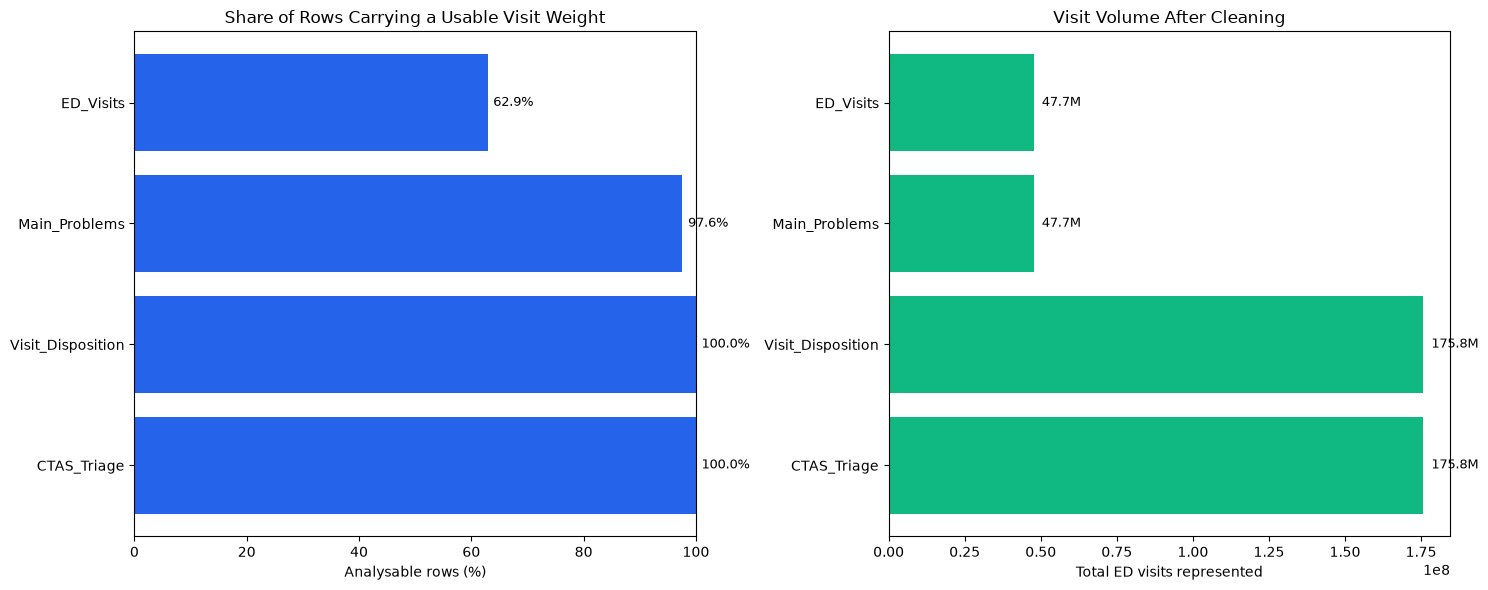

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(coverage_df["dataset"], coverage_df["coverage_%"], color="#2563EB")
axes[0].set_xlabel("Analysable rows (%)")
axes[0].set_title("Share of Rows Carrying a Usable Visit Weight")
axes[0].set_xlim(0, 100)

for i, v in enumerate(coverage_df["coverage_%"]):
    axes[0].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)

axes[1].barh(coverage_df["dataset"], coverage_df["total_visits"], color="#10B981")
axes[1].set_xlabel("Total ED visits represented")
axes[1].set_title("Visit Volume After Cleaning")

for i, v in enumerate(coverage_df["total_visits"]):
    axes[1].text(v, i, f"  {v/1e6:.1f}M", va="center", fontsize=9)

plt.tight_layout()
plt.show()

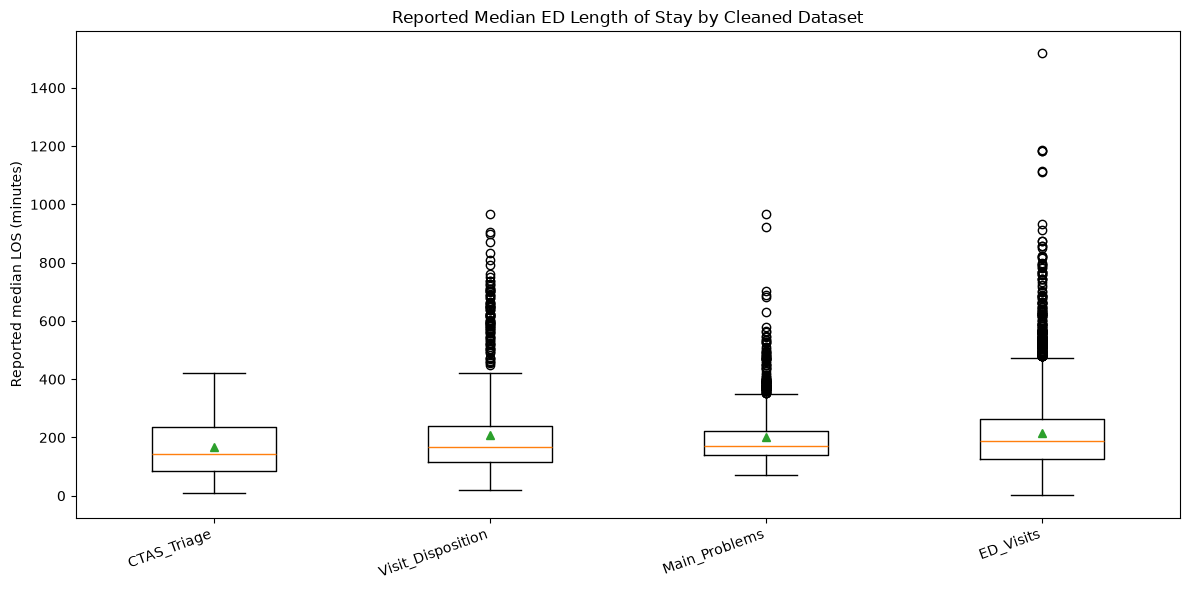

In [23]:
# Distribution of reported median LOS across the cleaned datasets that carry it.

los_sets = {
    n: d.loc[(d["is_suppressed"] == 0) & d["median_los_minutes"].notna(), "median_los_minutes"]
    for n, d in clean_frames.items()
    if "median_los_minutes" in d.columns and "is_suppressed" in d.columns
}

los_sets = {n: s for n, s in los_sets.items() if len(s) > 0}

fig, ax = plt.subplots(figsize=(12, 6))

ax.boxplot(list(los_sets.values()), tick_labels=list(los_sets), showmeans=True)
ax.set_ylabel("Reported median LOS (minutes)")
ax.set_title("Reported Median ED Length of Stay by Cleaned Dataset")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# WRITE CLEANED OUTPUT
# ============================================================
# Same file names, new directory. backend/database/load_csv.py prefers this folder,
# so the pipeline picks the cleaned data up without any other change.

written = []

for name, df in clean_frames.items():
    path = CLEAN_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    written.append({"file": path.name, "rows": len(df), "columns": df.shape[1]})
    print(f"  wrote {path.name:24} {len(df):>6,} rows")

display(pd.DataFrame(written))

  wrote CTAS_Triage.csv             912 rows
  wrote Visit_Disposition.csv       936 rows
  wrote Main_Problems.csv         1,063 rows
  wrote ED_Visits.csv             5,586 rows
  wrote Demographics.csv             36 rows


,file,rows,columns
0,CTAS_Triage.csv,912,11
1,Visit_Disposition.csv,936,13
2,Main_Problems.csv,1063,11
3,ED_Visits.csv,5586,12
4,Demographics.csv,36,7


In [25]:
# ============================================================
# VERIFY THE PIPELINE CONSUMES THE CLEANED FILES
# ============================================================
from backend.database.load_csv import CLEAN_CSV_DIR, resolve_csv_source

print("Loader cleaned-CSV directory :", CLEAN_CSV_DIR)
print()

for name in DATASETS:
    source = resolve_csv_source(name)
    label = "cleaned" if source and source.parent == CLEAN_DIR else "raw"
    print(f"  {name:20} -> {label:8} {source.name if source else 'not found'}")

Loader cleaned-CSV directory : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-\data\Explorer Dataset\cleaned

  CTAS_Triage          -> cleaned  CTAS_Triage.csv
  Visit_Disposition    -> cleaned  Visit_Disposition.csv
  Age_Sex              -> raw      not found
  Main_Problems        -> cleaned  Main_Problems.csv
  ED_Visits            -> cleaned  ED_Visits.csv
  Demographics         -> cleaned  Demographics.csv


In [26]:
print("=" * 80)
print("SUMMARY")
print("=" * 80)

total_in = int(report_df["rows_in"].sum())
total_out = int(report_df["rows_out"].sum())

print(f"Datasets cleaned : {len(clean_frames)}")
print(f"Rows in          : {total_in:,}")
print(f"Rows out         : {total_out:,}")
print(f"Rows removed     : {total_in - total_out:,}")
print()
print("Corrected:")
print("  - age_group and population_category canonicalised across every export,")
print("    so a join on age_group now matches between files.")
print("  - median_los_hours recomputed from the authoritative minutes column.")
print("  - Duplicate merge artefact columns (population_category.1) dropped.")
print("  - Column names normalised to snake_case.")
print()
print("Flagged, not deleted:")
print("  - is_suppressed marks CIHI-suppressed cells (reported as 0 visits).")
print("    The rows remain visible in the explorer; the hypothesis engines")
print("    already filter them via 'WHERE ed_visits > 0'.")
print()
print("Removed:")
print("  - Roll-up rows only ('Total', 'Any'). They double counted every visit,")
print("    and any total remains recoverable by summing the detail rows.")
print()
print("Measured values were never imputed or rewritten.")
print()
print("Rebuild the analytical database with:")
print("  python -m backend.database.load_csv")

SUMMARY
Datasets cleaned : 5
Rows in          : 10,243
Rows out         : 8,533
Rows removed     : 1,710

Corrected:
  - age_group and population_category canonicalised across every export,
    so a join on age_group now matches between files.
  - median_los_hours recomputed from the authoritative minutes column.
  - Duplicate merge artefact columns (population_category.1) dropped.
  - Column names normalised to snake_case.

Flagged, not deleted:
  - is_suppressed marks CIHI-suppressed cells (reported as 0 visits).
    The rows remain visible in the explorer; the hypothesis engines
    already filter them via 'WHERE ed_visits > 0'.

Removed:
  - Roll-up rows only ('Total', 'Any'). They double counted every visit,
    and any total remains recoverable by summing the detail rows.

Measured values were never imputed or rewritten.

Rebuild the analytical database with:
  python -m backend.database.load_csv
